DICCIONARIO DE DATOS: COFFE QUALITY DATASET

1. Identidad y Trazabilidad

 - Unnamed: 0: Índice numérico residual del archivo original; no tiene valor analítico.
 
 - Species: Tipo de especie botánica (Arabica o Robusta).
 
 - Owner / Owner.1: Persona o entidad dueña del lote de café.

 - Country.of.Origin: País de procedencia del grano.

 - Farm.Name: Nombre de la finca productora.

 - Lot.Number: Código de identificación del lote específico.

 - Mill: Nombre del beneficio o planta donde se procesó el café.

 - ICO.Number: Registro internacional ante la International Coffee Organization.

 - Company: Empresa exportadora o comercializadora.

 - Region: Zona geográfica específica dentro del país de origen.

 - Producer: Nombre del productor o caficultor.

 - In.Country.Partner: Organización que coordina la certificación en el país origen (ej. Almacafé).

2. Logística y Certificación

 - Number.of.Bags: Cantidad total de sacos en el lote.

 - Bag.Weight: Peso de cada saco individual.

 - Harvest.Year: Periodo o año de la cosecha.

 - Grading.Date: Fecha en la que se realizó la evaluación técnica.

 - Expiration: Fecha límite de validez de la certificación.

 - Certification.Body: Entidad encargada de emitir el certificado de calidad.

 - Certification.Address / Contact: Datos de ubicación y contacto de la certificadora.

3. Atributos Sensoriales

 - Aroma: Fragancia del café en seco y su olor al contacto con agua caliente.

 - Flavor: Intensidad y calidad del sabor percibido.

 - Aftertaste: Calidad del sabor remanente tras la degustación.

 - Acidity: Nivel de brillantez y viveza del grano.

 - Body: Textura y sensación de peso en el paladar.

 - Balance: Equilibrio entre aroma, sabor, acidez y cuerpo.

 - Uniformity: Consistencia de sabor entre las distintas tazas de la muestra.

 - Clean.Cup: Ausencia de sabores defectuosos o "sucios".

 - Sweetness: Presencia de dulzor natural en el grano.

 - Cupper.Points: Calificación global otorgada por el catador.

 - Total.Cup.Points: Variable objetivo (Target). Puntaje final sobre 100 puntos.

4. Atributos Físicos y Defectos

 - Moisture: Grado de humedad del grano verde.

 - Color: Tono visual del café (Verde, Azulado, etc.).

 - Category.One.Defects: Conteo de defectos primarios (los más graves).

 - Category.Two.Defects: Conteo de defectos secundarios (leves).

 - Quakers: Granos que no se tuestan bien por falta de madurez.

5. Altitud

 - Altitude: Texto original con la información de altura (sin procesar).

 - unit_of_measurement: Unidad utilizada en el registro original (ft o m).

 - altitude_low_meters: Valor mínimo del rango de altitud en metros.

 - altitude_high_meters: Valor máximo del rango de altitud en metros.

 - altitude_mean_meters: Promedio de altitud calculado y normalizado

# 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cargar el Dataset

In [2]:
df_merged = pd.read_csv("../data/raw/merged_data_cleaned.csv")

# 3. Vista Inicial del Dataset

In [3]:
df_merged.head(3)

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0


In [4]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1339 non-null   int64  
 1   Species                1339 non-null   object 
 2   Owner                  1332 non-null   object 
 3   Country.of.Origin      1338 non-null   object 
 4   Farm.Name              980 non-null    object 
 5   Lot.Number             276 non-null    object 
 6   Mill                   1021 non-null   object 
 7   ICO.Number             1180 non-null   object 
 8   Company                1130 non-null   object 
 9   Altitude               1113 non-null   object 
 10  Region                 1280 non-null   object 
 11  Producer               1107 non-null   object 
 12  Number.of.Bags         1339 non-null   int64  
 13  Bag.Weight             1339 non-null   object 
 14  In.Country.Partner     1339 non-null   object 
 15  Harv

In [5]:
df_merged.describe()

,Unnamed: 0,Number.of.Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Category.Two.Defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1338.000000,1339.000000,1109.000000,1109.000000,1109.000000
mean,669.000000,154.182972,7.566706,7.520426,7.401083,7.535706,7.517498,7.518013,9.834877,9.835108,9.856692,7.503376,82.089851,0.088379,0.479462,0.173393,3.556385,1750.713315,1799.347775,1775.030545
std,386.680316,129.987162,0.377560,0.398442,0.404463,0.379827,0.370064,0.408943,0.554591,0.763946,0.616102,0.473464,3.500575,0.048287,2.549683,0.832121,5.312541,8669.440545,8668.805771,8668.626080
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,334.500000,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,7.250000,81.080000,0.090000,0.000000,0.000000,0.000000,1100.000000,1100.000000,1100.000000
50%,669.000000,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,10.000000,10.000000,10.000000,7.500000,82.500000,0.110000,0.000000,0.000000,2.000000,1310.640000,1350.000000,1310.640000
75%,1003.500000,275.000000,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,10.000000,10.000000,10.000000,7.750000,83.670000,0.120000,0.000000,0.000000,4.000000,1600.000000,1650.000000,1600.000000
max,1338.000000,1062.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,10.000000,90.580000,0.280000,63.000000,11.000000,55.000000,190164.000000,190164.000000,190164.000000


Hallazgos Críticos en el Análisis Estadístico:

1. Inconsistencia en Altitud: Presencia de outliers extremos (190km+) que distorsionan la media. Requiere tratamiento por mediana o filtrado físico.

2. Registros Truncados: Valores mínimos de 0.0 en variables sensoriales indican datos faltantes o errores de carga que deben ser removidos.

3. Baja Variabilidad: Atributos como 'Sweetness' y 'Clean.Cup' presentan una concentración excesiva en el valor máximo (10.0), aportando poco valor predictivo.

# 4. Detección duplicados en la columna ID

In [6]:
primera_col = df_merged.columns[0]
total_dups_col1 = df_merged[primera_col].duplicated().sum()
total_unicos_col1 = len(df_merged) - total_dups_col1

print(f"Análisis de la columna: '{primera_col}'")
print(f"Registros Duplicados: {total_dups_col1}")
print(f"Registros Únicos: {total_unicos_col1}")

Análisis de la columna: 'Unnamed: 0'
Registros Duplicados: 0
Registros Únicos: 1339


La columna 'Unnamed: 0' funciona como un índice primario de facto. Al no presentar registros duplicados y coincidir con el total de filas del dataset (1339), se confirma que no existen ingresos de datos idénticos o 'clones' completos en el archivo de origen

# 5. Cantidad de muestras por especie de café

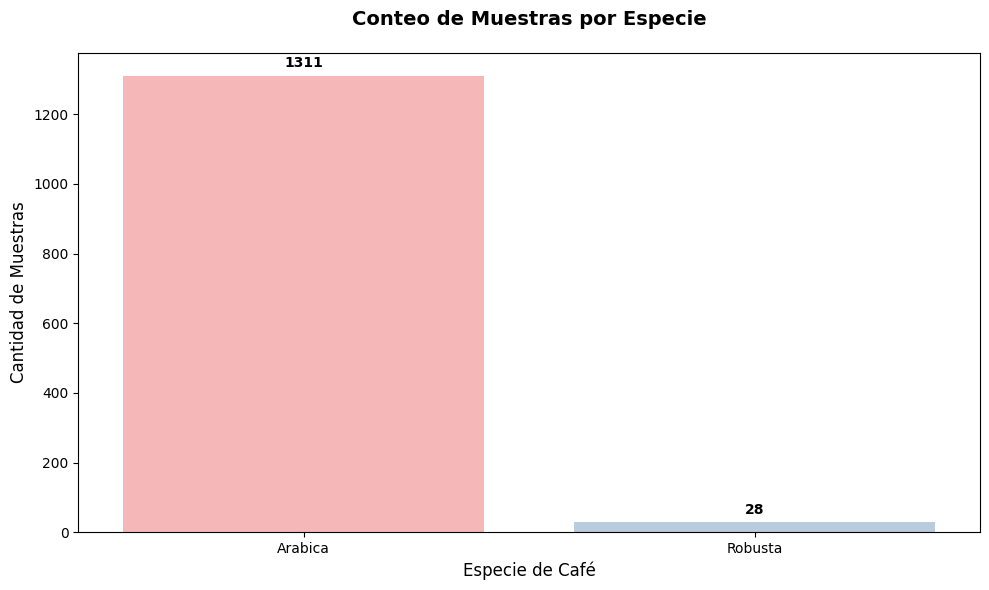

In [7]:
plt.figure(figsize=(10, 6))
if 'Species' in df_merged.columns:
    sns.countplot(data=df_merged, x='Species', hue='Species', palette=['#ffadad', '#b3cde3'], legend=False)
    
    plt.title("Conteo de Muestras por Especie", fontsize=14, weight='bold', pad=20)
    plt.xlabel("Especie de Café", fontsize=12)
    plt.ylabel("Cantidad de Muestras", fontsize=12)
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 9), 
                     textcoords='offset points', 
                     weight='bold')

plt.tight_layout()
plt.show()

Se identifica un fuerte desbalance de clases entre Arabica (n=1311) y Robusta (n=28). Esta disparidad justifica el tratamiento diferenciado de variables como la altitud y el método de procesamiento durante la etapa de limpieza, evitando que la mayoría (Arabica) diluya las particularidades de la minoría (Robusta)

# 6. Tipos de unidad de medida para la distancia sobre el nivel del mar

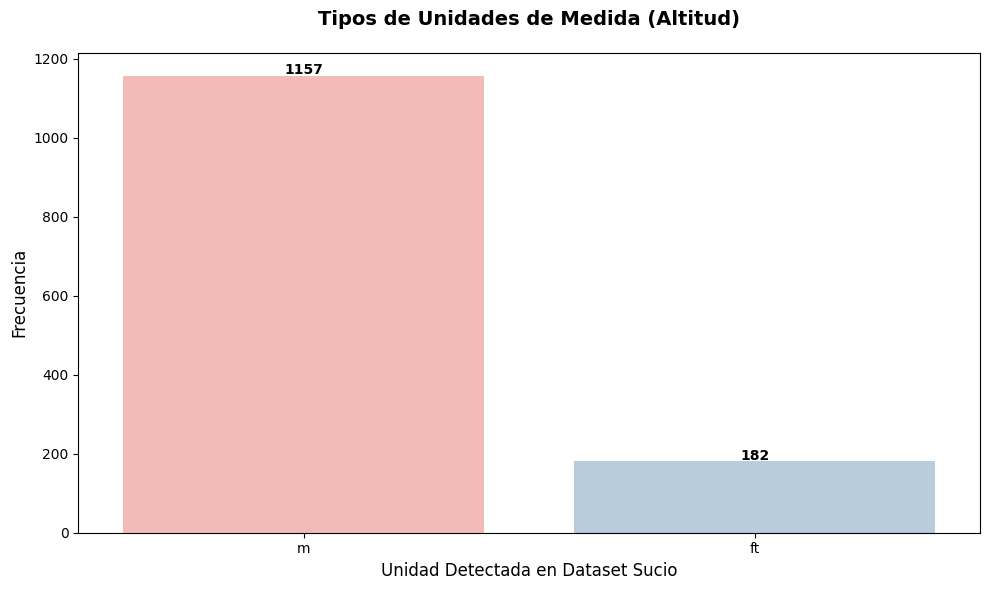

In [8]:
plt.figure(figsize=(10, 6))

if 'unit_of_measurement' in df_merged.columns:
    unit_data = df_merged['unit_of_measurement'].value_counts(dropna=False)
    
    # Aquí hacemos lo mismo: asignamos el índice a 'hue'
    sns.barplot(x=unit_data.index.astype(str), y=unit_data.values, 
                hue=unit_data.index.astype(str), palette='Pastel1', legend=False)
    
    plt.title("Tipos de Unidades de Medida (Altitud)", fontsize=14, weight='bold', pad=20)
    plt.xlabel("Unidad Detectada en Dataset Sucio", fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    
    for i, v in enumerate(unit_data.values):
        plt.text(i, v + 3, str(v), ha='center', weight='bold')

plt.tight_layout()
plt.show()

Se detectó una coexistencia de unidades (m y ft) en la medición de altitud. Para garantizar la integridad estadística y la comparabilidad de las muestras, se justifica la aplicación de una función de conversión técnica que unifica el 100% de los registros a metros (m) antes de proceder con el análisis de outliers y el modelado.

# 7. Identificación de valores faltantes (nulos)

In [9]:
# 1. Conteo de nulos por columna (solo las que tienen al menos 1 nulo)
nulos_por_columna = df_merged.isnull().sum()
nulos_solo_con_datos = nulos_por_columna[nulos_por_columna > 0]

# 2. Calculamos el porcentaje para tener contexto
porcentaje_nulos = (nulos_solo_con_datos / len(df_merged)) * 100

# 3. Creamos un resumen rápido
resumen_nulos = pd.DataFrame({
    'Cantidad': nulos_solo_con_datos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
}).sort_values(by='Cantidad', ascending=False)

print("--- Columnas con Valores Faltantes ---")
if not resumen_nulos.empty:
    print(resumen_nulos)
else:
    print("¡Felicidades! No se detectaron nulos en ninguna columna.")

--- Columnas con Valores Faltantes ---
                      Cantidad  Porcentaje (%)
Lot.Number                1063           79.39
Farm.Name                  359           26.81
Mill                       318           23.75
Color                      270           20.16
Producer                   232           17.33
altitude_high_meters       230           17.18
altitude_low_meters        230           17.18
altitude_mean_meters       230           17.18
Altitude                   226           16.88
Variety                    226           16.88
Company                    209           15.61
Processing.Method          170           12.70
ICO.Number                 159           11.87
Region                      59            4.41
Harvest.Year                47            3.51
Owner.1                      7            0.52
Owner                        7            0.52
Country.of.Origin            1            0.07
Quakers                      1            0.07


El análisis de nulos reveló una criticidad extrema en Lot.Number (79% de faltantes), justificando su descarte inmediato. Para el resto de las variables con nulos moderados (12% al 20%), como la altitud y variedades, se optó por una estrategia de imputación jerárquica para preservar la integridad del volumen de datos (1339 muestras) sin introducir sesgos significativos

# 8. Composición de Variables Categóricas (Incluyendo Nulos)

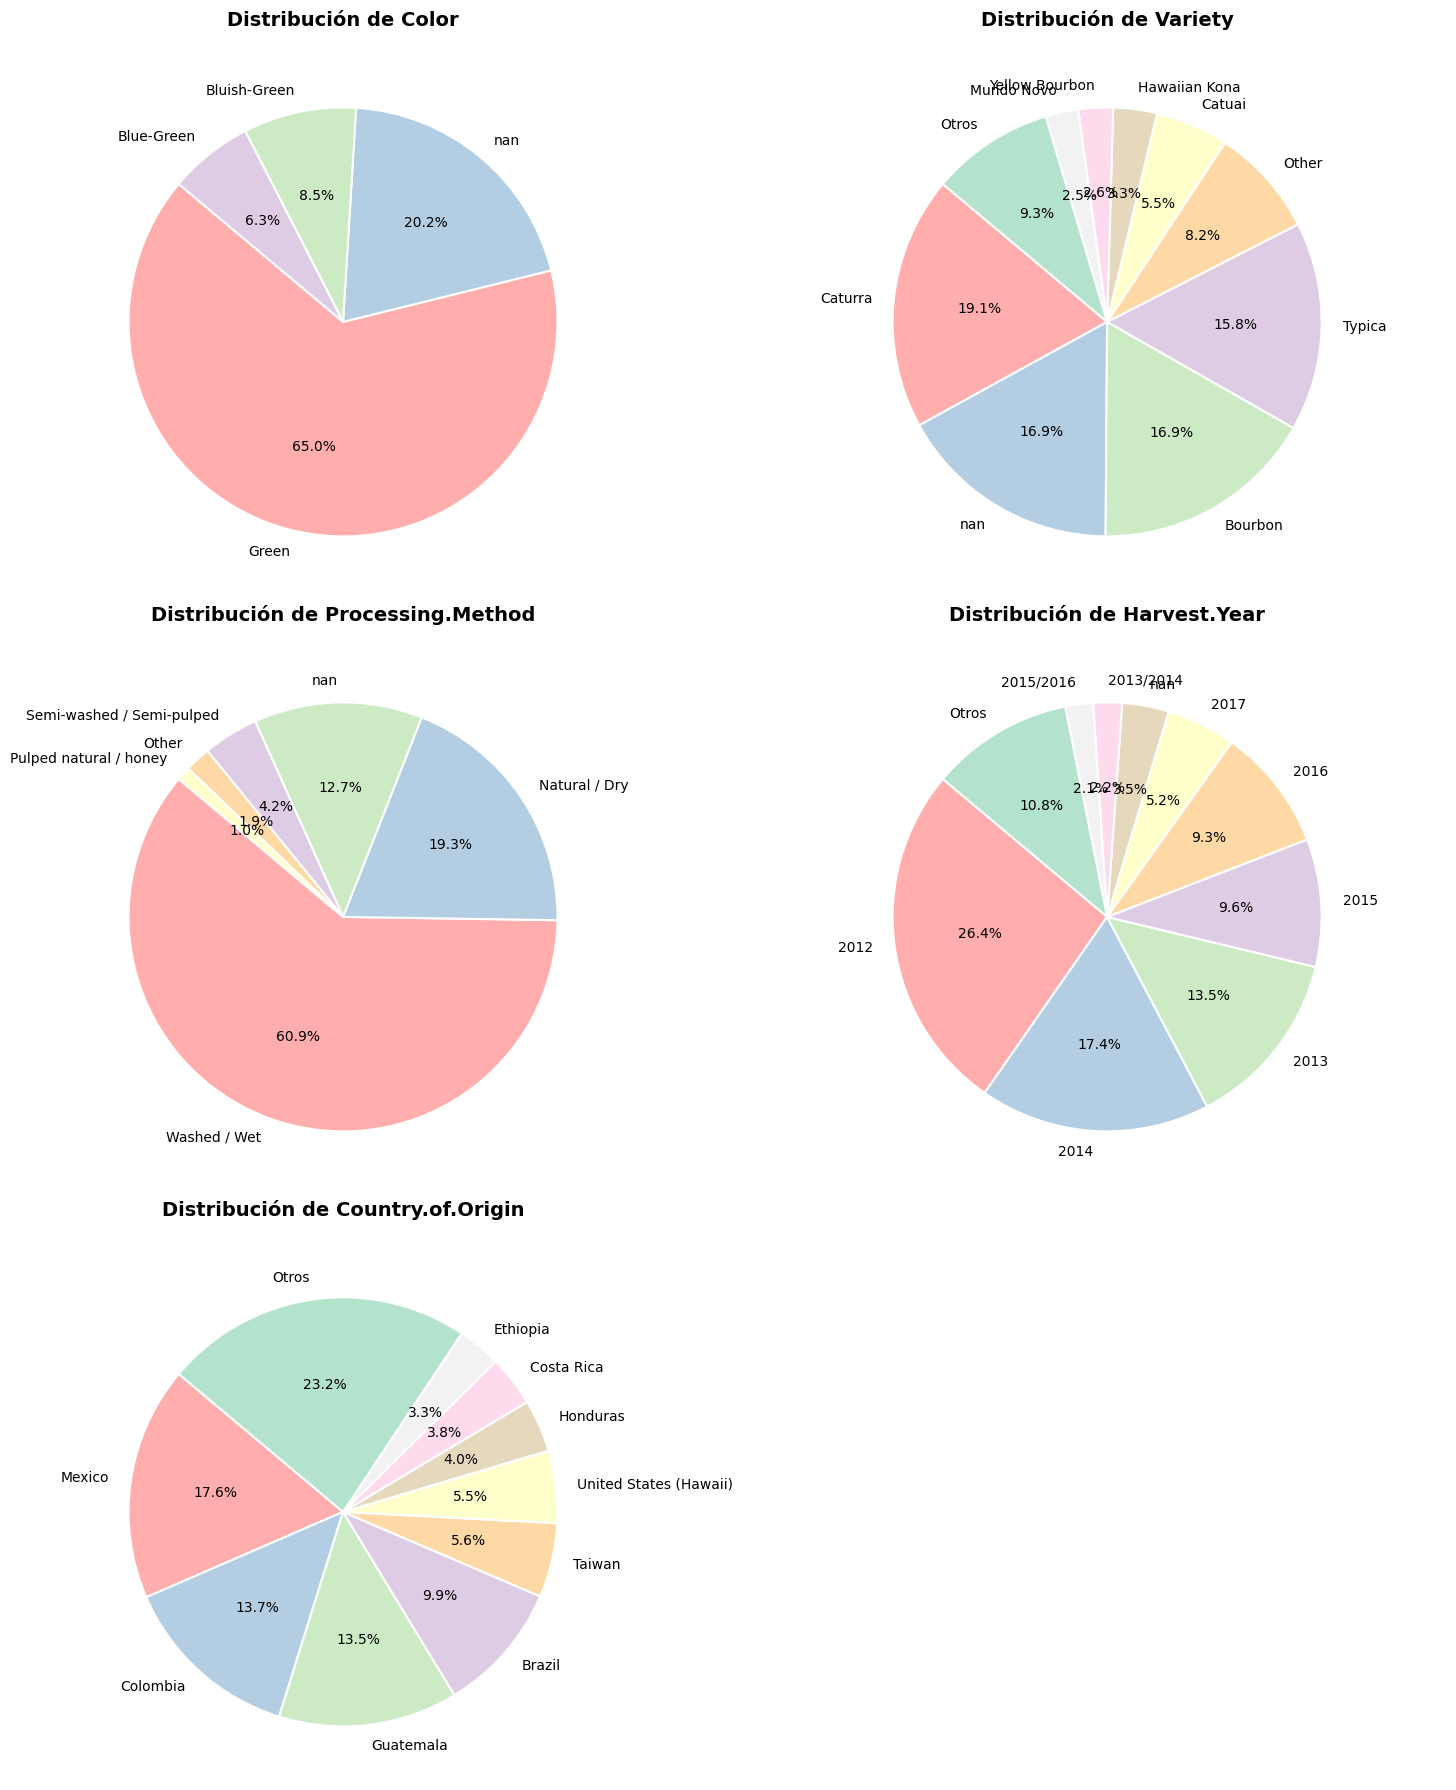

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Definimos las columnas
cols_interes = ['Color', 'Variety', 'Processing.Method', 'Harvest.Year', 'Country.of.Origin']

# 2. Configuramos la grilla
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

# Definimos el rojo extra tenue (un tono pastel suave)
rojo_muy_tenue = '#ffadad' 

for i, col in enumerate(cols_interes):
    if col in df_merged.columns:
        # Obtenemos las frecuencias incluyendo nulos
        data = df_merged[col].value_counts(dropna=False)
        
        # Agrupamos si hay demasiadas categorías
        if len(data) > 10:
            top_data = data.head(9)
            otros_data = pd.Series({'Otros': data.iloc[9:].sum()})
            data = pd.concat([top_data, otros_data])
        
        # --- LÓGICA DE COLORES ---
        # Usamos la paleta Pastel1 como base
        colores_finales = list(plt.cm.Pastel1.colors)
        
        # Extendemos la paleta si es necesario para que no falten colores
        while len(colores_finales) < len(data):
            colores_finales += list(plt.cm.Pastel2.colors)
            
        # Reemplazamos la porción mayor (índice 0) por el rojo extra tenue
        colores_finales[0] = rojo_muy_tenue
        
        # Graficamos
        axes[i].pie(data, 
                    labels=data.index, 
                    autopct='%1.1f%%', 
                    startangle=140, 
                    colors=colores_finales[:len(data)], 
                    textprops={'fontsize': 10},
                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        
        axes[i].set_title(f"Distribución de {col}", fontsize=14, weight='bold', pad=20)
    else:
        axes[i].axis('off')

# Ocultar el último cuadro si sobra
if len(cols_interes) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

Los gráficos de torta revelan una alta concentración de las muestras en categorías dominantes, especialmente en el origen y el color. La presencia significativa de la categoría 'Otros' en variables como la variedad botánica justifica la normalización de etiquetas realizada, simplificando la complejidad del dataset sin perder la representatividad de las clases mayoritarias.

# 9. Identificación de Valores Atipicos (Outliers)

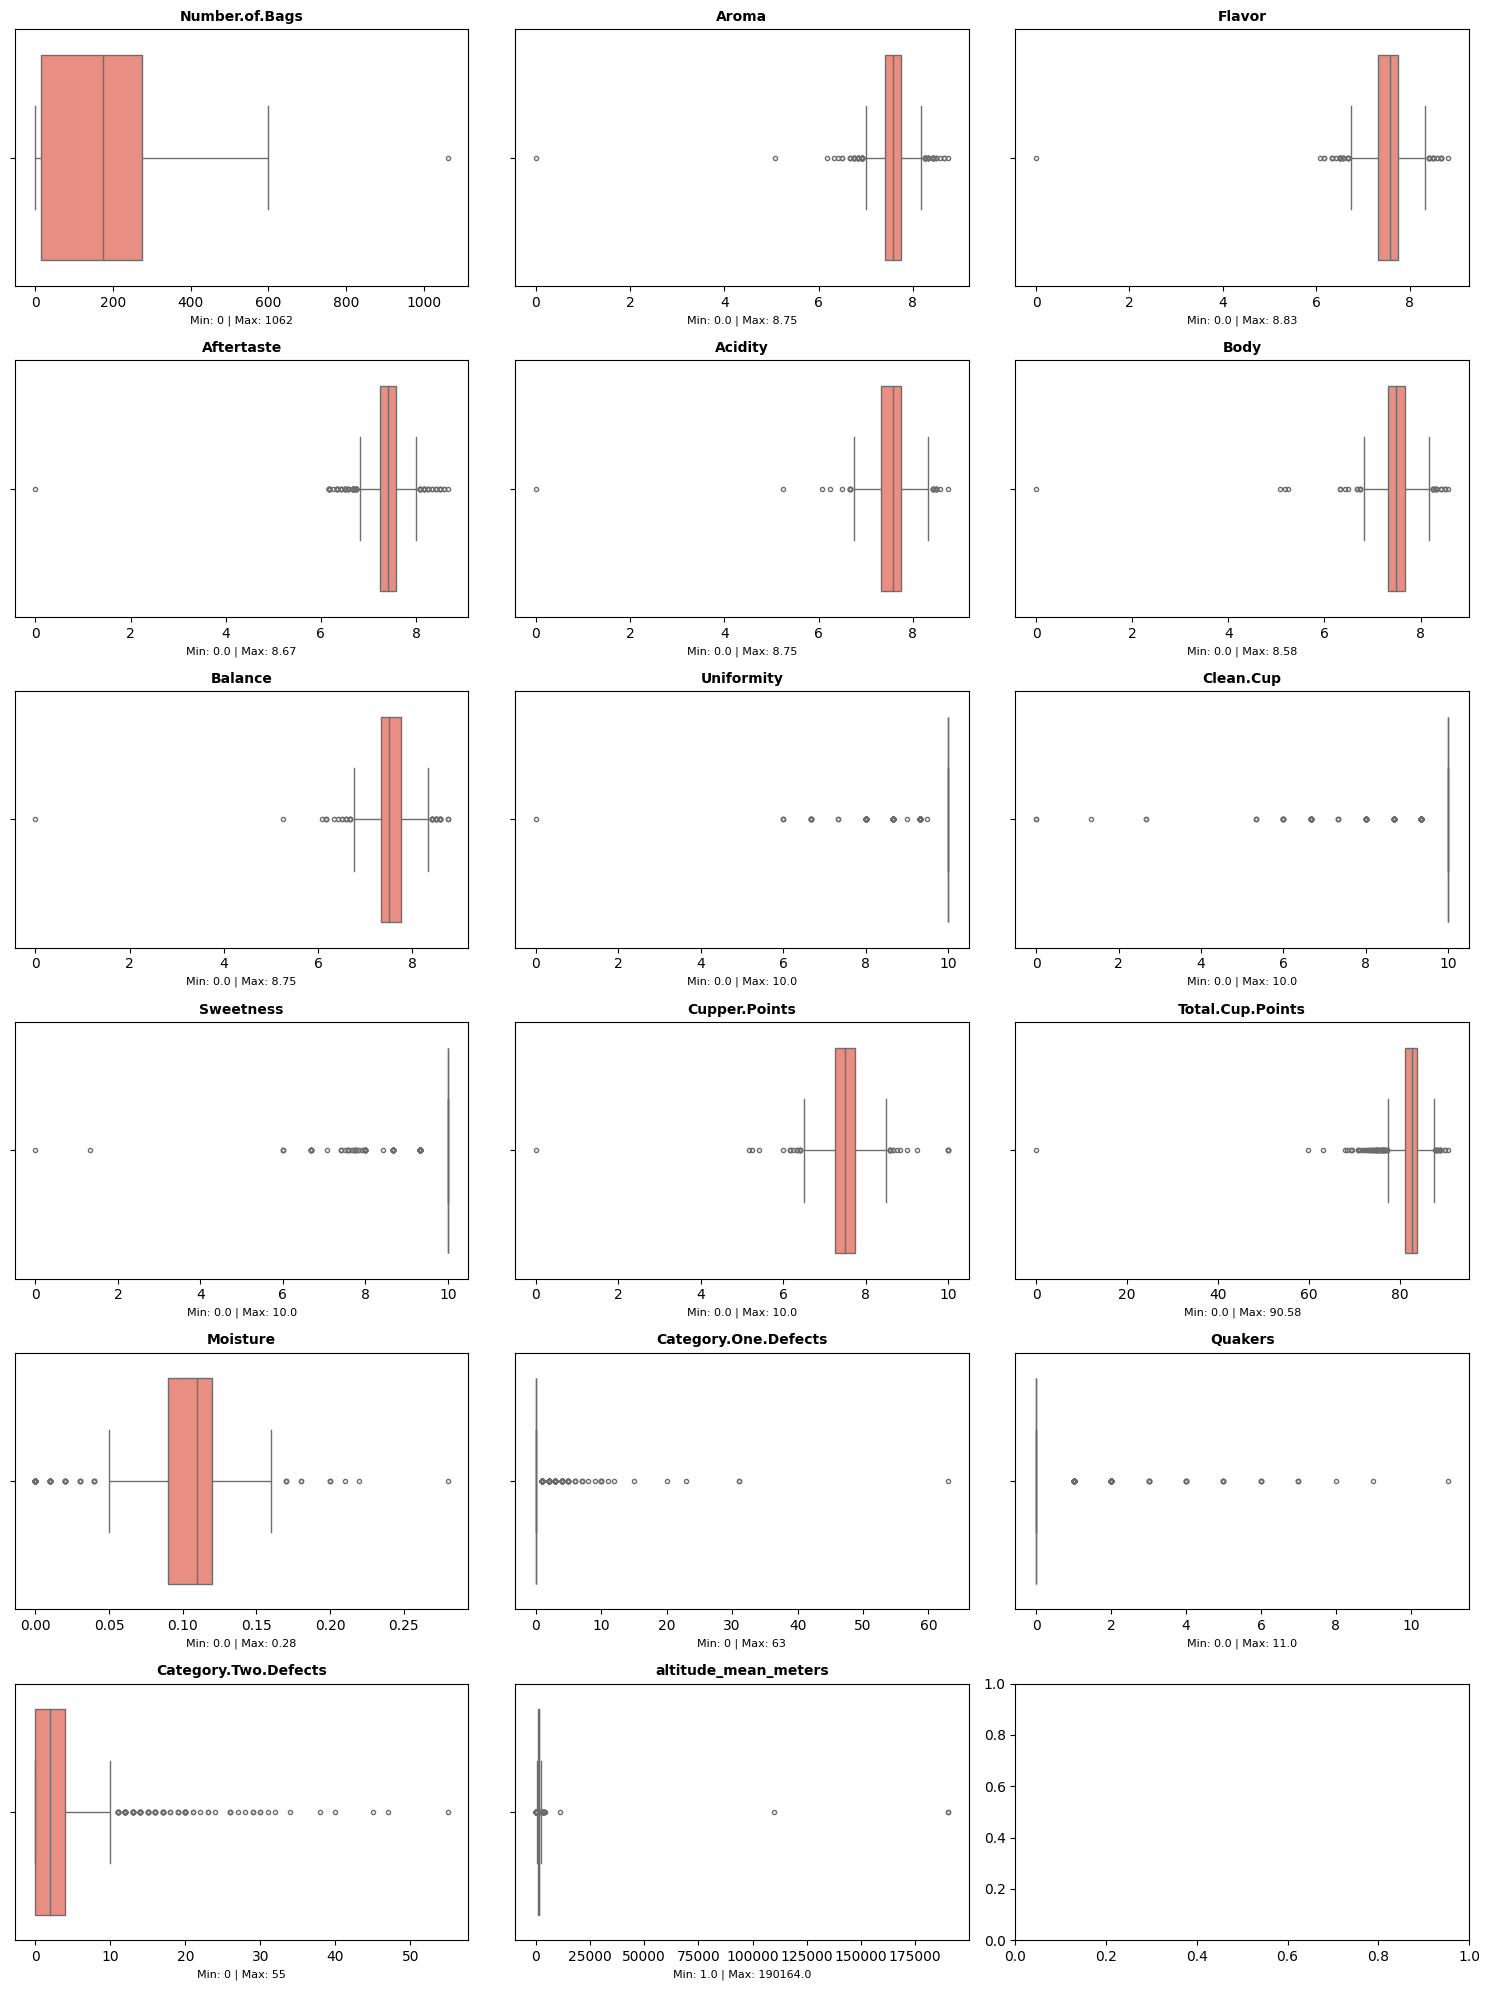

In [11]:
cols_numericas = [
    'Number.of.Bags', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 
    'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 
    'Cupper.Points', 'Total.Cup.Points', 'Moisture', 
    'Category.One.Defects', 'Quakers', 'Category.Two.Defects',
    'altitude_mean_meters'
]
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    if col in df_merged.columns:
        sns.boxplot(x=df_merged[col], ax=axes[i], color='salmon', fliersize=3)
        v_min, v_max = df_merged[col].min(), df_merged[col].max()
        axes[i].set_title(f"{col}", fontsize=10, weight='bold')
        axes[i].set_xlabel(f"Min: {v_min} | Max: {v_max}", fontsize=8)
        axes[i].set_ylabel("")
    else:
        axes[i].set_visible(False)
plt.tight_layout()
plt.show()

Se identificaron tres comportamientos críticos:

1. Ruido en Variables Sensoriales: Presencia de registros con valor 0.0, inconsistentes con la naturaleza del café de especialidad.

2. Sesgo Extremo en Altitud: Outliers que superan los 100km de altura, confirmando errores de unidad o carga.

3. Ausencia de Varianza: Atributos como 'Sweetness' y 'Uniformity' presentan una dispersión nula, justificando su exclusión para simplificar el modelo predictivo."

# 10. Densidad y tendencia central de atributos sensoriales

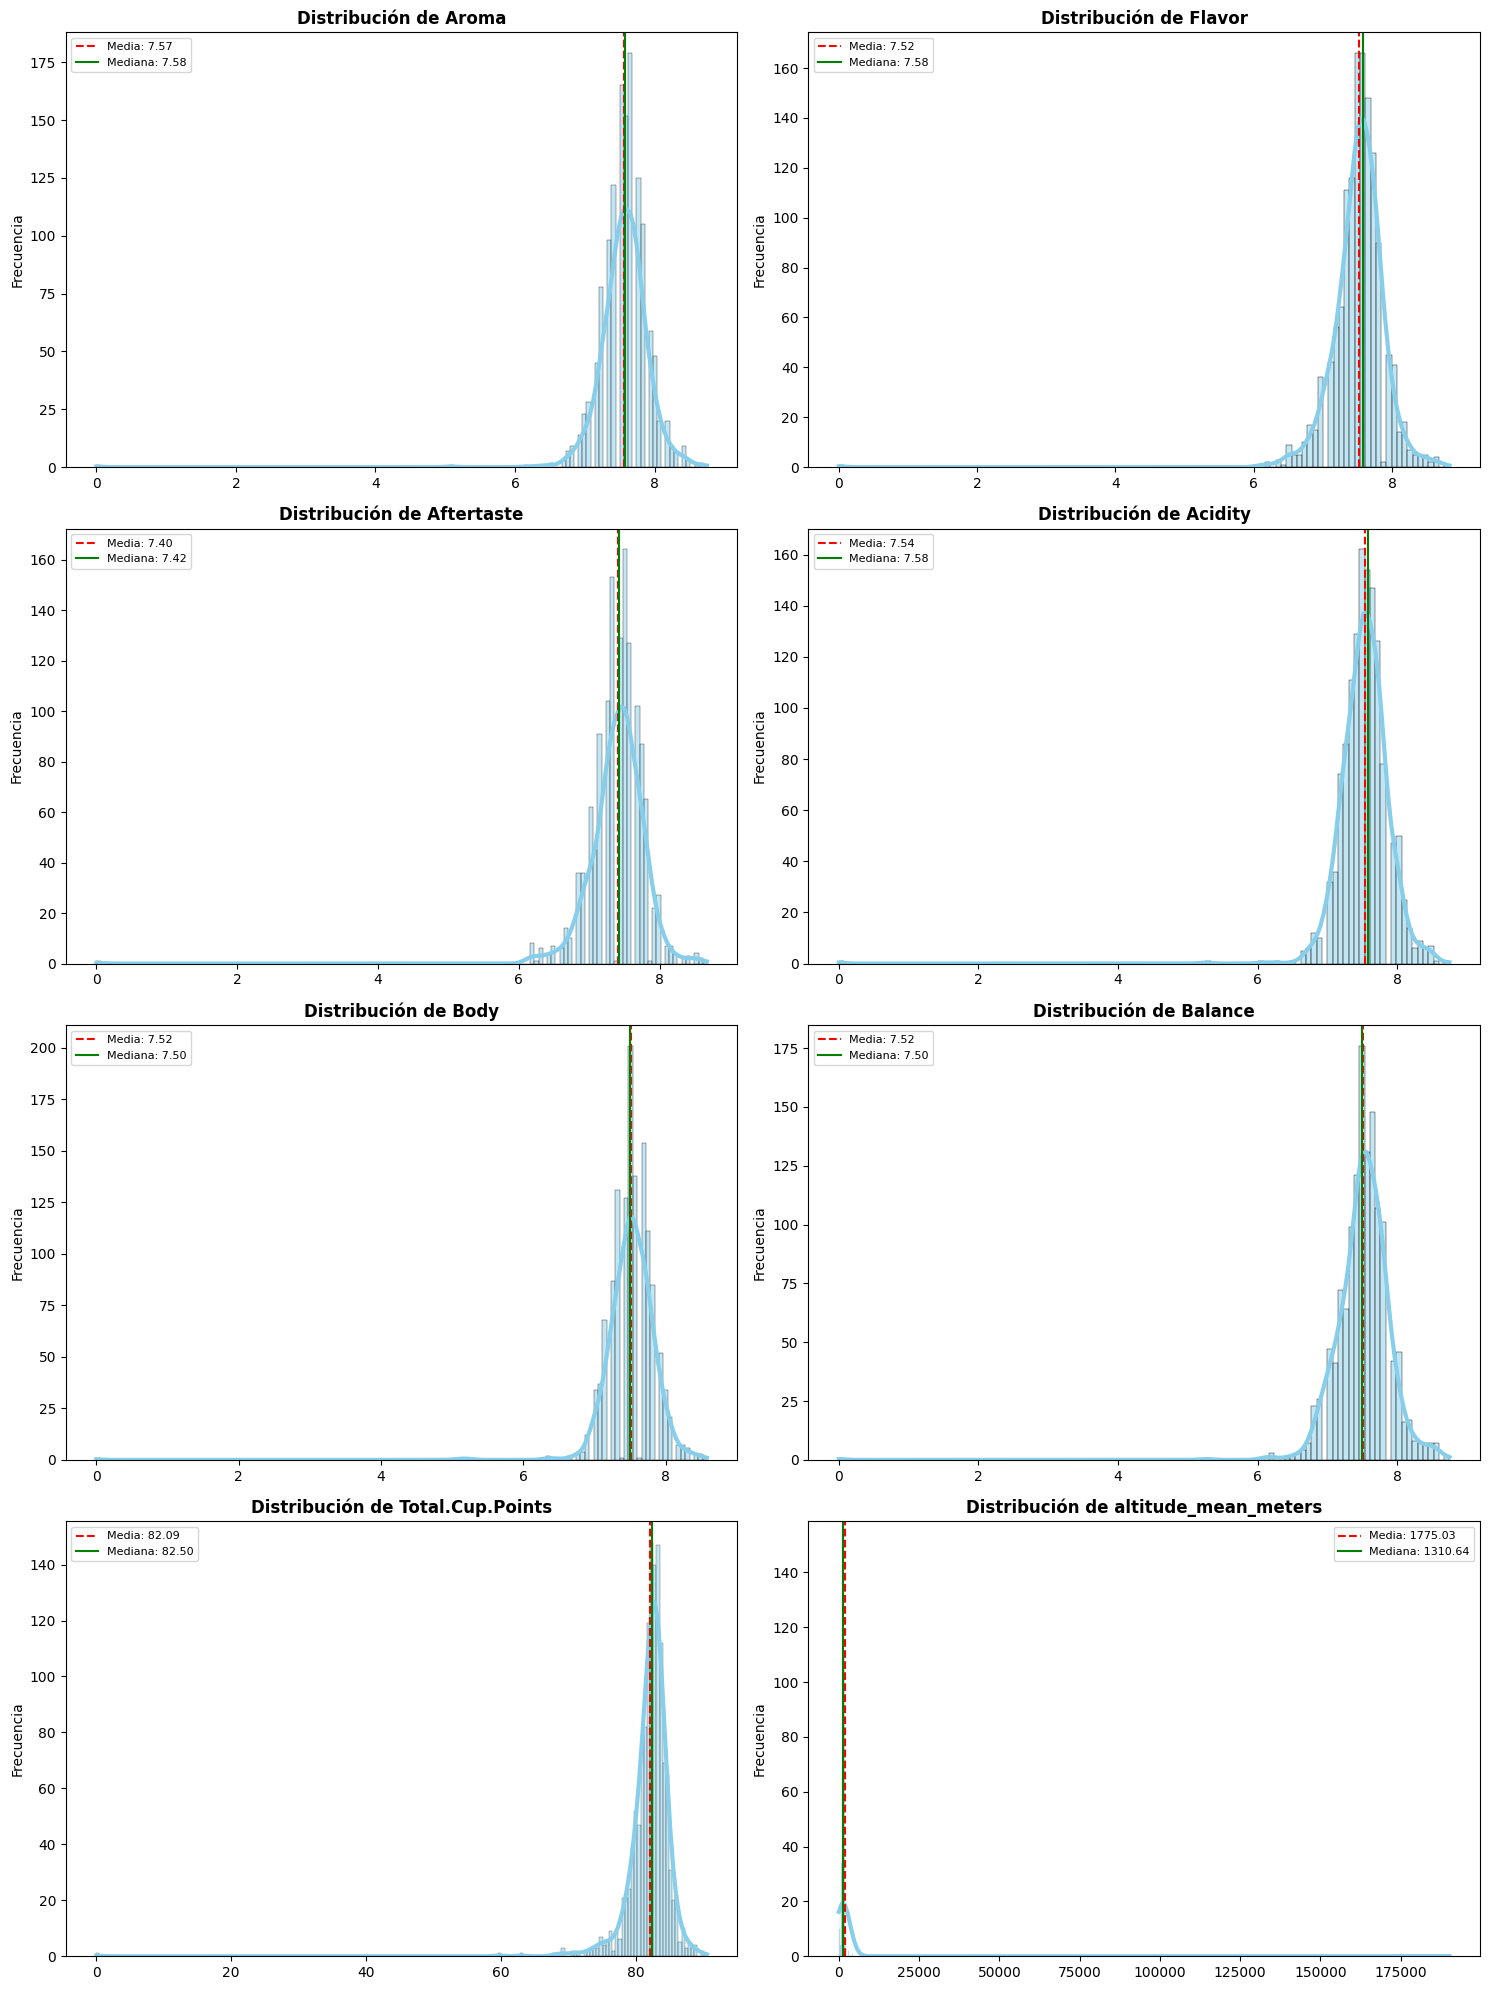

In [12]:
# 1. Definimos las variables de interés (puntajes y métricas clave)
cols_dist = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 
    'Body', 'Balance', 'Total.Cup.Points', 'altitude_mean_meters'
]

# 2. Configuramos la grilla (4 filas x 2 columnas)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_dist):
    if col in df_merged.columns:
        # Graficamos el histograma con la línea de densidad (KDE)
        # Usamos el rojo tenue que te gustó para la línea
        sns.histplot(df_merged[col], kde=True, ax=axes[i], color='skyblue', line_kws={'color': '#ffadad', 'lw': 3})
        
        # Títulos y detalles
        axes[i].set_title(f"Distribución de {col}", fontsize=12, weight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frecuencia")
        
        # Agregamos una línea vertical para la media y la mediana para ver el sesgo
        mean_val = df_merged[col].mean()
        median_val = df_merged[col].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
        axes[i].legend(fontsize=8)
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

Los histogramas revelan un sesgo negativo en los atributos sensoriales, provocado por valores atípicos en el extremo inferior de la escala. La divergencia entre la media y la mediana en la variable de altitud confirma la distorsión causada por errores de medición, validando el uso de técnicas de imputación robustas (medianas) y la necesidad de un filtrado de registros incompletos para normalizar la muestra